In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.market_loader import MarketLoader

from src.curves.curve_snapshot import CurveSnapshot
from src.curves.bootstrap.bootstrap_engine import BootstrapCurveEngine
from src.curves.projection_curve import ProjectionCurve
from src.curves.zero_curve import ZeroCurve
from src.curves.simulator.hull_white_2factor import HullWhite2FactorSimulator
from src.curves.simulator.hull_white_2factor_pricer import HullWhite2FactorPricer
from src.curves.calibrator.pca_factor_extractor import PCAFactorExtractor
from src.curves.calibrator.ou_factor_calibrator import OUFactorCalibrator

from src.pricing.hull_white_2factor_swap_pricer import HullWhite2FactorSwapPricer

from src.instruments.instrument_builder import InstrumentBuilder

from src.trades.interest_rate_swap import InterestRateSwap

from src.risk.exposure.stochastic_exposure_engine_2factor import MonteCarloExposureEngine2Factor
from src.risk.credit.stochastic_hazard_rate import StochasticHazardRateSimulator

In [2]:
# downloading market curves
market_loader = MarketLoader()
market_curves = market_loader.market_loader_pipeline()

# downloading swap curves
swap_loader = MarketLoader()
swap_curves = swap_loader.swap_loader_pipeline()

treasury curve dataset already downloaded..
sofr curve dataset already downloaded..
futures curve dataset already downloaded..
estr curve dataset already downloaded..
usd_ois curve dataset already downloaded..
eur_ois curve dataset already downloaded..


In [3]:
# yield curve history
curve_history = market_curves['treasury']
curve_history = curve_history / 100

In [4]:
### create curve snapshots
# SOFR snapshot
sofr_df = market_curves['sofr']

latest_date = sofr_df.index[-1]
latest_sofr_curve = sofr_df.iloc[-1]

sofr_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'sofr',
    as_of_date = latest_date,
    curve_row = latest_sofr_curve
)

# Futures snapshot
future_df = market_curves['futures']
latest_futures_curve = future_df.iloc[-1]

futures_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'futures',
    as_of_date = latest_date,
    curve_row = latest_futures_curve
)

# OIS snapshot
ois_df = swap_curves['usd_ois']

latest_swap_date = ois_df.index[-1]
latest_swap_curve = ois_df.iloc[-1]

ois_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'usd_ois',
    as_of_date = latest_swap_date,
    curve_row = latest_swap_curve
)

In [5]:
### create instruments from curve snapshot
# deposits
deposit_instruments = InstrumentBuilder.build_deposit_instruments(snapshot = sofr_snapshot)

# futures
future_instruments = InstrumentBuilder.build_future_instruments(snapshot = futures_snapshot)

# ois
ois_instruments = InstrumentBuilder.build_ois_instruments(snapshot = ois_snapshot)

### discount, projection and zero curve builder
# bootstrapping engine for generating the discount curve
all_instruments = deposit_instruments + future_instruments + ois_instruments

engine = BootstrapCurveEngine()

discount_curve = engine.bootstrap(
    snapshot = sofr_snapshot,
    instruments = all_instruments
)

# projection curve
projection_curve = ProjectionCurve(discount_curve = discount_curve)

# zero curve
zero_curve = ZeroCurve(discount_curve = discount_curve)

In [6]:
# sample IRS trade objects
IR_swap = InterestRateSwap(
    notional = 1_000_000,
    maturity = 3.0,
    fixed_rate = 3.40,
    pay_fixed = True
)

In [7]:
### PCA factor extractor
# initialize PCA factor extractor
pca = PCAFactorExtractor(n_factors = 2)

# fitting PCAs to historical yield changes and projecting onto factors
factor_history = pca.fit_transform(yield_curve_history = curve_history)

In [8]:
# Ornstein-Uhlenbeck factor calibration
ou_calibrator = OUFactorCalibrator(dt = 1/252)

# calibrate HW 2-factor model parameters
hw2f_params = ou_calibrator.calibrate_hw2f(factor_history = factor_history)
hw2f_params

{'a': 0.0994245389493929,
 'b': 0.06493166163063027,
 'sigma1': 0.018724138829696178,
 'sigma2': 0.008874071471247505,
 'rho': -0.0006194015774373465}

In [9]:
### HW 2-factor simulator using calibrated HW 2-factor model parameters
# short rate
r0 = zero_curve.get_zero_rate(maturity = 0.25)

# simulator engine
hw_simulator = HullWhite2FactorSimulator(
    r0 = r0,
    a = hw2f_params['a'],
    b = hw2f_params['b'],
    sigma1 = hw2f_params['sigma1'],
    sigma2 = hw2f_params['sigma2'],
    rho = hw2f_params['rho'],
    random_seed = 2
)

# hw pricer
hw_pricer = HullWhite2FactorPricer(
    zero_curve = zero_curve,
    a = hw2f_params['a'],
    b = hw2f_params['b'],
    sigma1 = hw2f_params['sigma1'],
    sigma2 = hw2f_params['sigma2'],
    rho = hw2f_params['rho']
)

# hw 2-factor swap pricer
hw_swap_pricer = HullWhite2FactorSwapPricer(hw_pricer = hw_pricer)

# exposure engine
hw2f_trade_engine = MonteCarloExposureEngine2Factor(
    pricer = hw_swap_pricer,
    simulator = hw_simulator
)

In [10]:
# trade-level baseline (uncollateralized) expected exposure
simulation_paths = 250
trading_days = 252

uncollateralized_ee = hw2f_trade_engine.expected_exposure(
    swap = IR_swap,
    n_paths = simulation_paths,
    steps_per_year = trading_days
)

uncollateralized_ee

,Times,EE
0,0.000000,11168.934638
1,0.003968,11157.199561
2,0.007937,10958.927056
3,0.011905,10851.875726
4,0.015873,11021.920831
...,...,...
752,2.984127,187.503220
753,2.988095,140.997655
754,2.992063,93.399581
755,2.996032,46.527468


In [11]:
# hazard rate simulator
hazard_simulator = StochasticHazardRateSimulator(
    lambda0 = 0.005,
    kappa = 1.10,
    theta = 0.020,
    eta = 0.010,
    random_seed = 2
)

# simulate sinle hazard path
hazard_path = hazard_simulator.simulate_single_path(
    maturity = IR_swap.maturity,
    steps_per_year = trading_days
)

hazard_path

,Times,HazardRate
0,0.000000,0.005000
1,0.003968,0.004803
2,0.007937,0.004834
3,0.011905,0.003554
4,0.015873,0.004659
...,...,...
752,2.984127,0.006606
753,2.988095,0.006614
754,2.992063,0.005858
755,2.996032,0.005080


In [12]:
hazard_path.iloc[:50]

,Times,HazardRate
0,0.000000,0.005000
1,0.003968,0.004803
2,0.007937,0.004834
3,0.011905,0.003554
4,0.015873,0.004659
5,0.019841,0.003597
6,0.023810,0.003138
7,0.027778,0.003528
8,0.031746,0.002816
9,0.035714,0.002224


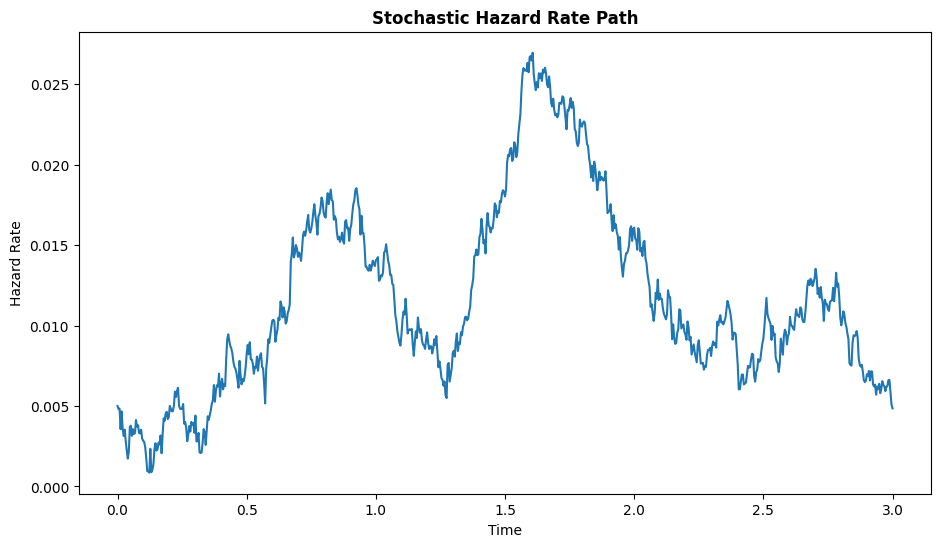

In [13]:
# plot simulated single hazard path
plt.figure(figsize = (11,6))

plt.plot(hazard_path['Times'], hazard_path['HazardRate'])

plt.title('Stochastic Hazard Rate Path', fontweight = 'bold')
plt.xlabel('Time')
plt.ylabel('Hazard Rate')
plt.show()

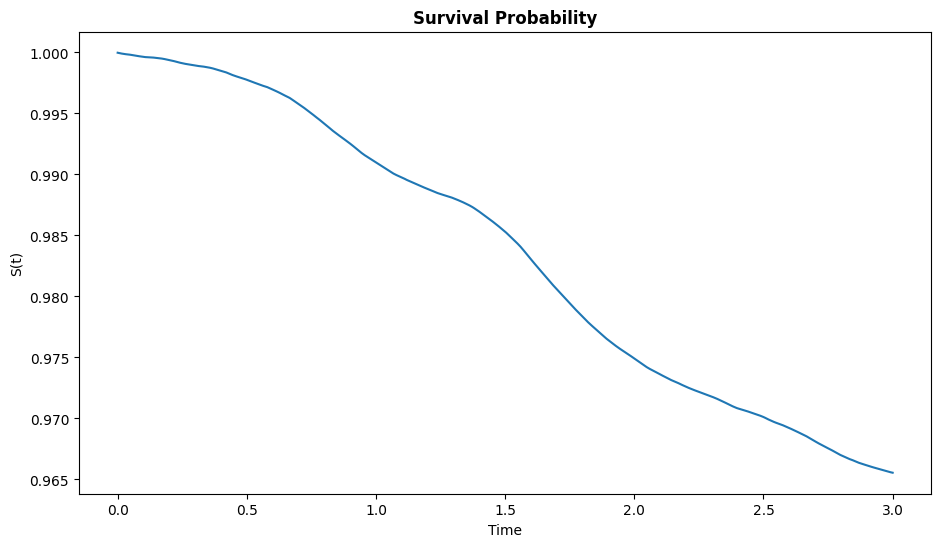

In [14]:
# survival probability
dt = 1.0 / trading_days

p_survival = hazard_simulator.survival_probability(
    hazard_path = hazard_path['HazardRate'].to_numpy(),
    dt = dt
)

# plot survival probability for a given hazard path
plt.figure(figsize=(11, 6))

plt.plot(hazard_path['Times'], p_survival)

plt.title('Survival Probability', fontweight = 'bold')
plt.xlabel('Time')
plt.ylabel('S(t)')
plt.show()

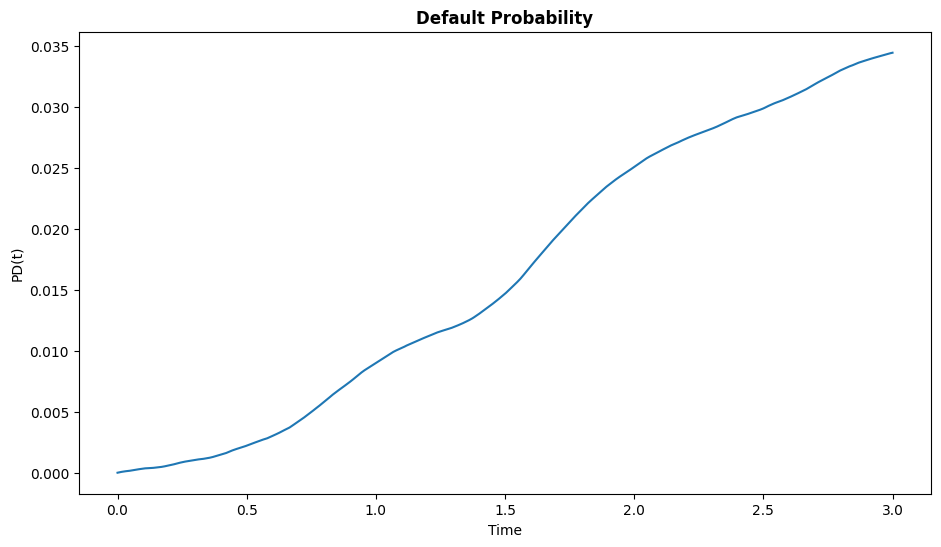

In [15]:
# default probability
p_default = hazard_simulator.default_probability(
    hazard_path = hazard_path['HazardRate'].to_numpy(),
    dt = dt
)

# plot default probability
plt.figure(figsize=(11, 6))

plt.plot(hazard_path['Times'], p_default)

plt.title('Default Probability', fontweight = 'bold')
plt.xlabel('Time')
plt.ylabel('PD(t)')
plt.show()

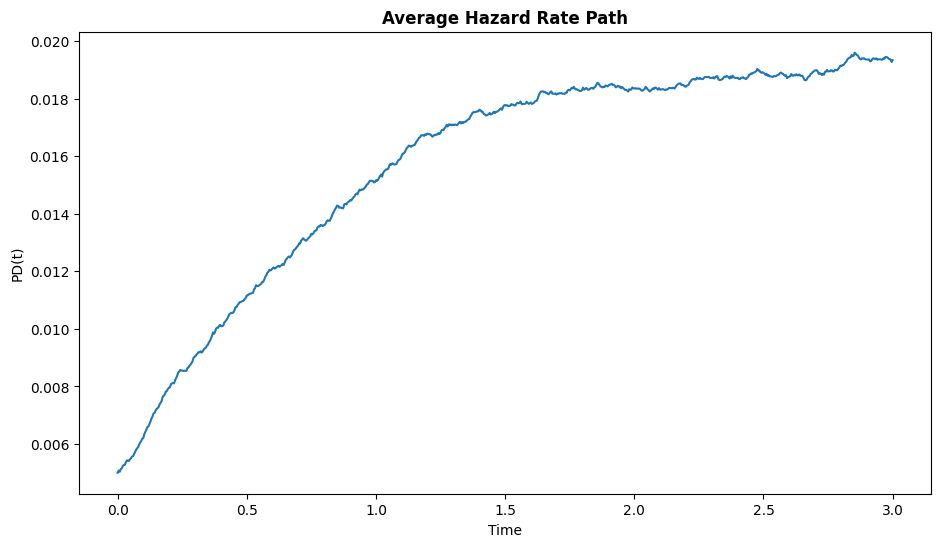

In [16]:
### average hazard across different simulation paths
# multi-path
simulation_paths = 250

hazard_paths = hazard_simulator.simulate_multi_paths(
    maturity = IR_swap.maturity,
    n_paths = simulation_paths,
    steps_per_year = trading_days
) 

# average hazard path across n_paths
avg_hazard_path = hazard_paths.mean(axis = 0)

# plot average hazard path
plt.figure(figsize = (11, 6))

plt.plot(hazard_path['Times'], avg_hazard_path)

plt.title('Average Hazard Rate Path', fontweight = 'bold')
plt.xlabel('Time')
plt.ylabel('PD(t)')
plt.show()